# Import de bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
from multiprocessing import cpu_count
from functools import partial
import time


# Ler base de dados

In [4]:
equipDB = pd.read_csv("EquipDB.csv", header=None, names=["ID_equipamento", "TempoAposFalha", "Cluster", "CustoDeFalha"])
ClusterDB= pd.read_csv("ClusterDB.csv", header=None, names=["ID_Cluster", "eta", "beta"])
MPDB=pd.read_csv("MPDB.csv", header=None, names=["ID_plano_risco", "Fator_risco(k)", "CustoDoPlano"])

# Unir informações do ClusterDB ao equipDB
equipDB = equipDB.merge(ClusterDB, left_on="Cluster", right_on="ID_Cluster")


# Formula de Weibull

$P_{ij}$ é a probabilidade de falha do equipmento $i$ sob o plano de manutenção $j$

In [5]:
def Fi(t, eta, beta):
    return 1-np.exp(-(t/eta)**beta)

def P(t0, eta, beta, k, delta_t):
    return (Fi((t0+k*delta_t), eta=eta, beta=beta)-Fi(t=t0, eta=eta, beta=beta))/(1-Fi(t=t0, eta=eta, beta=beta))

# Modelo Matematicos

## Conjuntos e Parâmetros
$I$: Conjunto de equipamentos ($|I| = 500$, $i \in I$)

$J = \{1,2,3\}$: Planos de manutenção disponíveis ($j \in J$)

$C = \{1,2,3,4\}$: Clusters de equipamentos ($c \in C$)

$t_0^i$: Idade atual do equipamento $i$ (em anos)

$\text{c}_i$: Cluster ao qual pertence o equipamento $i$

$\text{f}_i$: Custo associado à falha do equipamento $i$

$k_j$: Fator de risco do plano de manutenção $j$

$\text{m}_j$: Custo de aplicar o plano $j$ a um equipamento

$\eta_c$: Parâmetro de escala (Weibull) para o cluster $c$

$\beta_c$: Parâmetro de forma (Weibull) para o cluster $c$

$p_{i,j}$: probabilidade de falha do equipmento $i$ sob o plano de manutenção $j$

$\Delta t = 5$ anos: Horizonte de planejamento


### Varaivel de decisão
$$
x_{i} \in J \quad \forall i \in I $$
$$

\begin{align}
f_1(\mathbf{x}) &=\min \sum_{i \in I} \text{m}_{ x_i} \quad \text{(Custo total de manutenção)} \\
f_2(\mathbf{x}) &= \min \sum_{i \in I}  p_{i,x_i} \cdot \text{f}_i \quad \text{(Custo esperado de falha)}
\end{align}$$
onde: 

$$
\begin{align}
p_{i,j} = \frac{F_{c(i)}(t_0^i + k_j \Delta t) - F_{c(i)}(t_0^i)}{1 - F_{c(i)}(t_0^i)} \\
F_c(t) = 1 - \exp\left[-\left(\frac{t}{\eta_c}\right)^{\beta_c}\right]
\end{align}$$


$$

## Variavel de decisão

In [6]:
# Criar a matriz  de probabilidade Pij
Pij = np.zeros((len(equipDB), len(MPDB)))
delta_t = 5  # Definir um valor para Delta_t,

for i, equipamento in equipDB.iterrows():
    t0 = equipamento["TempoAposFalha"]
    eta = equipamento["eta"]
    beta = equipamento["beta"]
    
    for j, plano in MPDB.iterrows():
        k = plano["Fator_risco(k)"]
        Pij[i, j] = P(t0, eta, beta, k, delta_t)

# Converter a matriz para um DataFrame para melhor visualização
Pij_df = pd.DataFrame(Pij, index=equipDB["ID_equipamento"], columns=MPDB["ID_plano_risco"])


## Geração Solução Inicial (Cálculo do Índice Crítico)
Para cada equipamento $i$, calcule o índice de criticidade:

$$
\text{Índice}_i = \text{custo\_falha}_i \times p_{i,\text{nenhuma}} \times t_0^i
$$

onde:

$\text{custo\_falha}_i$: Custo associado à falha do equipamento $i$

$p_{i,\text{nenhuma}}$: Probabilidade de falha se nenhuma manutenção for aplicada (plano $j=1$)

$t_0^i$: Tempo de operação

## Alocação de Planos de Manutenção

Ordene os equipamentos em ordem $\textbf{decrescente}$ de $\text{Índice}_i$ e aloque os planos:


$\textbf{Top 20\%}$ equipamentos: Manutenção detalhada (plano $j=3$)


$\textbf{Próximos 30\%}$: Manutenção intermediária (plano $j=2$)

$\textbf{Restante 50\%}$: Nenhuma manutenção (plano $j=1$)

In [7]:
# Heurística construtiva baseada em criticidade
def gerar_solucao_inicial(equipDB, MPDB, Pij):
    criticidade = equipDB["CustoDeFalha"].values * Pij[:, 0] 
    ordem = np.argsort(-criticidade)
    solucao = np.ones(len(equipDB), dtype=int)
    n = len(equipDB)
    for idx, i in enumerate(ordem):
        if idx < 0.2 * n:
            solucao[i] = 3
        elif idx < 0.5 * n:
            solucao[i] = 2
        else:
            solucao[i] = 1
    return solucao

gerar_solucao_inicial(equipDB, MPDB, Pij)

array([2, 3, 3, 1, 1, 1, 2, 2, 3, 2, 1, 2, 1, 2, 2, 2, 2, 1, 1, 3, 3, 3,
       2, 1, 1, 3, 1, 3, 3, 1, 1, 1, 3, 1, 3, 3, 2, 1, 1, 1, 3, 1, 1, 1,
       2, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 3, 1, 3, 2, 1, 1, 1, 1, 2,
       2, 2, 1, 2, 3, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 3, 1, 1, 2, 1, 3,
       2, 2, 2, 3, 1, 2, 1, 3, 1, 1, 2, 3, 3, 3, 1, 1, 2, 1, 1, 1, 3, 1,
       1, 1, 1, 1, 3, 2, 2, 1, 1, 2, 3, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1,
       3, 1, 1, 1, 2, 1, 3, 2, 1, 1, 1, 2, 3, 3, 2, 3, 3, 2, 2, 2, 3, 1,
       1, 2, 1, 1, 3, 3, 1, 1, 3, 1, 3, 3, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1,
       2, 1, 3, 2, 1, 2, 2, 1, 3, 3, 2, 3, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1,
       3, 2, 1, 3, 1, 3, 1, 1, 1, 2, 3, 3, 1, 1, 2, 1, 1, 1, 1, 2, 3, 1,
       1, 2, 3, 2, 2, 1, 1, 3, 3, 3, 1, 1, 3, 1, 1, 2, 1, 1, 1, 2, 1, 2,
       1, 1, 2, 1, 3, 1, 1, 1, 1, 2, 2, 3, 2, 3, 3, 1, 1, 1, 2, 3, 2, 1,
       1, 2, 1, 2, 2, 1, 2, 1, 1, 3, 2, 2, 2, 1, 1, 2, 1, 2, 1, 3, 1, 1,
       3, 2, 1, 3, 2, 1, 2, 1, 1, 1, 3, 1, 1, 1, 1,

### Calcula o fit do ploblema

In [8]:
def f1(X, equipDB, MPDB, Pij):
    """
    Calcula o custo total de manutenção.

    Parâmetros:
    - x: matriz numpy (n x 3) representando as variáveis de decisão x_{i,j}
    - m: vetor numpy (3,) representando os custos de manutenção m_j para cada coluna

    Retorna:
    - Custo total de manutenção (float)
    """
    return sum(MPDB.iloc[p - 1]["CustoDoPlano"] for p in X)

def f2(X, equipDB, MPDB, Pij):
    """
    Calcula o custo esperado de falha.

    Parâmetros:
    - x: matriz numpy (n x 3) representando as variáveis de decisão x_{i,j}
    - p: matriz numpy (n x 3) representando as probabilidades de falha p_{i,j}
    - f: vetor numpy (n,) representando os custos de falha f_i

    Retorna:
    - Custo esperado de falha (float)
    """
    return sum(
        Pij[i, X[i] - 1] * equipDB.loc[i, "CustoDeFalha"]
        for i in range(len(X))
    )
# print("Custo total de manutenção:",f1(Xij))
# print("Custo esperado de falha:", f2(Xij))


## Gerar tres estruturas de vizinhaça

### Vizinhança 1 - Move

Move altera o plano de um dos equipamentos

### Vizinhaça 2 - double_move
Altera o plano de até 2 equipamentos distintos

### Vizinhaça 3 - block_change
Altera aleatoriamente o plano de manutenção de um bloco de até 50 maquinas consecutivas


In [9]:
def move(X):
    nova = X.copy()
    seed = int(time.time_ns() % (2**32))
    np.random.seed(seed)
    i = np.random.randint(len(X))
    nova[i] = np.random.choice([x for x in [1, 2, 3] if x != X[i]])
    return nova

# Vizinhança 2 - 1-opt entre planos
def double_move(X):
    nova = X.copy()
    seed = int(time.time_ns() % (2**32))
    np.random.seed(seed)
    i, j = np.random.choice(len(X), 2, replace=False)
    for idx in [i, j]:
        nova[idx] = np.random.choice([x for x in [1, 2, 3] if x != X[idx]])
    return nova

def block_change(X):
    nova = X.copy()
    seed = int(time.time_ns() % (2**32))
    np.random.seed(seed)
    if len(X) < 50:
        return move(X)
    i = np.random.randint(0, len(X) - 50)
    for j in range(i, i + 50):
        nova[j] = np.random.choice([x for x in [1, 2, 3] if x != X[j]])
    return nova

vizinhas = [move, double_move, block_change]

In [9]:
# Busca local
def busca_local(solucao, obj_func, *args):
    melhor = solucao.copy()
    melhor_valor = obj_func(melhor, *args)
    for viz in vizinhas:
        candidato = viz(melhor)
        valor = obj_func(candidato, *args)
        if valor < melhor_valor:
            return candidato
    return melhor

In [10]:
def GVNS(obj_func, gerar_solucao_inicial, vizinhas, busca_local, *args, max_iter=1000, return_curve=False):
    """
    Executa o algoritmo GVNS (Variable Neighborhood Search).
    """
    s = gerar_solucao_inicial(*args)
    melhor = s.copy()
    historico = []

    valor_inicial = obj_func(melhor, *args)
    historico.append(valor_inicial)

    for _ in range(max_iter):
        k = 0
        while k < len(vizinhas):
            s_ = vizinhas[k](melhor)
            s__ = busca_local(s_, obj_func, *args)
            novo_valor = obj_func(s__, *args)
            if novo_valor < historico[-1]:
                melhor = s__.copy()
                historico.append(novo_valor)
                k = 0
            else:
                k += 1
                historico.append(historico[-1])

    return (melhor, historico) if return_curve else melhor



# Execução principal com 5 repetições
def exec_fs_mono_obj():
    args = (equipDB, MPDB, Pij)
    resultados_f1 = [GVNS(f1, gerar_solucao_inicial, vizinhas, busca_local, *args,max_iter=1000, return_curve=True) for _ in range(5)]
    resultados_f2 = [GVNS(f2, gerar_solucao_inicial, vizinhas, busca_local, *args,max_iter=1000, return_curve=True) for _ in range(5)]

    custos_f1 = [f1(sol, equipDB, MPDB, Pij) for sol, _ in resultados_f1]
    custos_f2 = [f2(sol, equipDB, MPDB, Pij) for sol, _ in resultados_f2]

    print("--- f1 (Custo de Manutenção) ---")
    print("Min:", np.min(custos_f1))
    print("Max:", np.max(custos_f1))
    print("Std:", np.std(custos_f1))

    print("\n--- f2 (Custo Esperado de Falha) ---")
    print("Min:", np.min(custos_f2))
    print("Max:", np.max(custos_f2))
    print("Std:", np.std(custos_f2))

    plt.figure()
    for _, hist in resultados_f1:
        plt.plot(hist, alpha=0.7)
    plt.title("Convergência GVNS - f1")
    plt.xlabel("Numero de Soluções Candidatas")
    plt.ylabel("Custo de Manutenção")
    plt.grid(True)
    plt.show()

    plt.figure()
    for _, hist in resultados_f2:
        plt.plot(hist, alpha=0.7)
    plt.title("Convergência GVNS - f2")
    plt.xlabel("Numero de Soluções Candidatas")
    plt.ylabel("Custo Esperado de Falha")
    plt.grid(True)
    plt.show()

In [11]:
one = np.ones(500, dtype=int)

min_f1 = f1(one,equipDB,MPDB,Pij)
max_f1 = f1(one+2,equipDB,MPDB,Pij)
min_f2 = f2(one+2,equipDB,MPDB,Pij)
max_f2 = f2(one,equipDB,MPDB,Pij)

print("Menor f1 possível",min_f1)
print("Maior f1 possível",max_f1)
print("Menor f2 possível",min_f2)
print("Maior f2 possível",max_f2)

Menor f1 possível 0.0
Maior f1 possível 1000.0
Menor f2 possível 1048.178807842068
Maior f2 possível 1745.489826708262


## Hiper Volume

In [12]:
def calcular_hipervolume_biobjetivo(solucoes, referencia):
    """
    Calcula o hipervolume para soluções biobjetivo (problema de minimização)
    com relação a um ponto de referência.
    """
    # Remove dominadas (opcional, mas recomendado)
    solucoes = remover_dominadas(solucoes)
    
    # Ordena por f1 crescente
    solucoes_ordenadas = sorted(solucoes, key=lambda x: x[0])
    
    hipervolume = 0.0
    for i, ponto in enumerate(solucoes_ordenadas):
        f1, f2 = ponto
        if i == len(solucoes_ordenadas) - 1:
            largura = referencia[0] - f1
        else:
            proximo_f1 = solucoes_ordenadas[i + 1][0]
            largura = proximo_f1 - f1

        altura = referencia[1] - f2
        
        if largura > 0 and altura > 0:
            hipervolume += largura * altura

    return hipervolume

def remover_dominadas(pontos):
    """Remove soluções dominadas."""
    nao_dominadas = []
    for p in pontos:
        dominado = False
        for q in pontos:
            if all(qi <= pi for qi, pi in zip(q, p)) and any(qi < pi for qi, pi in zip(q, p)):
                dominado = True
                break
        if not dominado:
            nao_dominadas.append(p)
    return nao_dominadas

## Otimization $P_w$

In [13]:
# --- Normalização da função objetivo ---
def normfObj(fobj, x, min_, max_, *args):
    """
    Normaliza o valor da função objetivo.
    """
    return (fobj(x, *args) - min_) / (max_ - min_)


# --- Função fábrica para criar a função objetivo com um W específico ---
def make_objf_Pw(W_local):
    """
    Retorna uma função objetivo ponderada com um valor W específico.
    """
    def objf_Pw(x, *args):
        return W_local * normfObj(f1, x, min_f1, max_f1, *args) + (1 - W_local) * normfObj(f2, x, min_f2, max_f2, *args)
    return objf_Pw


# --- Wrapper para execução paralela ---
def run_gvns_wrapper_Pw(_):
    """
    Wrapper para a execução paralela do GVNS, retornando a solução e o peso W.
    """
    try:
        
        seed = int(time.time_ns() % (2**32))
        np.random.seed(seed)
        vizinhancas = [move, double_move, block_change]
        args = (equipDB, MPDB, Pij)
        W_local = random.uniform(0, 1)
        obj_func = make_objf_Pw(W_local)
        resultado = GVNS(obj_func, gerar_solucao_inicial, vizinhancas, busca_local, *args, max_iter=1000, return_curve=True)
        return resultado, W_local  # Retorna a solução e o W utilizado

    except Exception as e:
        print(f"[ERRO] Subprocesso falhou: {e}")
        return None


def executar_uma_repeticao_Pw():
    with ProcessPoolExecutor(max_workers=10) as executor:
        resultados_com_pesos = list(executor.map(run_gvns_wrapper_Pw, range(it)))
    return resultados_com_pesos

def filtrar_pareto_nao_dominado(pontos):
    """Retorna apenas os pontos não dominados (fronteira de Pareto)"""
    pontos = np.array(pontos)
    n = pontos.shape[0]
    is_dominado = np.zeros(n, dtype=bool)

    for i in range(n):
        for j in range(n):
            if i != j:
                # Dominância: queremos minimizar f1 e f2
                if (pontos[j][0] <= pontos[i][0] and pontos[j][1] <= pontos[i][1]) and \
                   (pontos[j][0] < pontos[i][0] or pontos[j][1] < pontos[i][1]):
                    is_dominado[i] = True
                    break
    return pontos[~is_dominado]


# Número de iterações a ser executado (por exemplo, 32 iterações)
it = 20 #intancias paraletas
repeticoes = 5

## Otimization $P_{\epsilon}$

In [14]:
def epsilons_f1():

    return np.random.random()*(max_f1-min_f1) + min_f1

def epsilons_f2():
    
    return np.random.random()*(max_f2-min_f2) + min_f2

epsilons = [epsilons_f2,epsilons_f1]

new_f_obj = [[f1,f2],[f2,f1]]

def make_objf_Pe(epsilon,num_func_obj=0, penalidade=100):
    f_obj = new_f_obj[num_func_obj][0]
    f_desig = new_f_obj[num_func_obj][1]

    def objf_Pe(x, *args):
        return f_obj(x, *args) + penalidade*max(f_desig(x, *args) - epsilon,0)
    return objf_Pe


def epsilon_restrito(_): # num_func_obj tem que ser 0 ou 1
    seed = int(time.time_ns() % (2**32))
    np.random.seed(seed)
    
    num_func_obj = np.random.choice([0,1])
    vizinhancas = [move, double_move, block_change]
    args = (equipDB, MPDB, Pij)
    epsilon = epsilons[num_func_obj]
    e = epsilon()

    f_obj_Pe = make_objf_Pe(e, num_func_obj=num_func_obj)
    resultado = GVNS(f_obj_Pe, gerar_solucao_inicial, vizinhancas, busca_local, *args, max_iter=1000, return_curve=True)
    return resultado, num_func_obj, epsilon

def executar_uma_repeticao_Pe():
    with ProcessPoolExecutor(max_workers=10) as executor:
        resultados_com_epsilon = list(executor.map(epsilon_restrito, range(it)))
    return resultados_com_epsilon


=== Repetição 1/5 ===

=== Repetição 2/5 ===

=== Repetição 3/5 ===

=== Repetição 4/5 ===

=== Repetição 5/5 ===


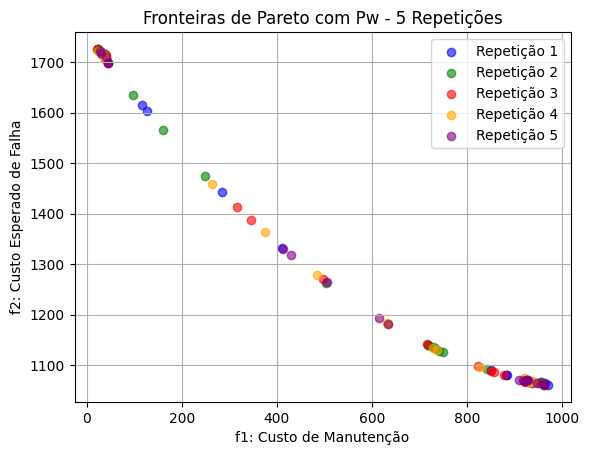

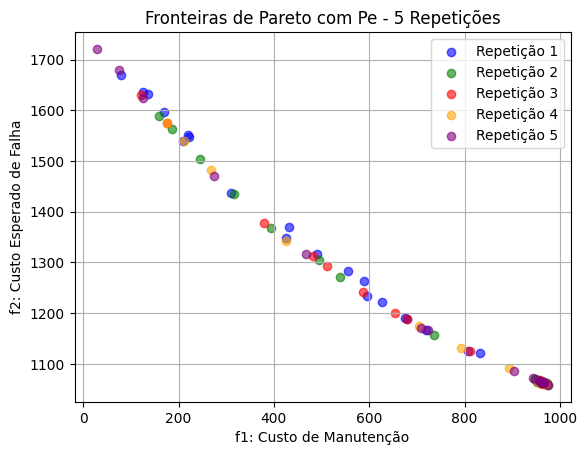

In [15]:

if __name__ == "__main__":
    todas_as_frentes_pareto_Pw = []
    todas_as_frentes_pareto_Pe = []

    for rep in range(repeticoes):
        print(f"\n=== Repetição {rep+1}/{repeticoes} ===")
        resultados_com_pesos = executar_uma_repeticao_Pw()
        resultados_com_epislons = executar_uma_repeticao_Pe()
        args = (equipDB, MPDB, Pij)

        # Separando os resultados e os Ws
        resultados_Pw = [r[0] for r in resultados_com_pesos]
        pesos_W = [r[1] for r in resultados_com_pesos]

        resultados_Pe = [r[0] for r in resultados_com_epislons]
        num_func_obj_Pe = [r[1] for r in resultados_com_epislons]
        epsilons = [r[2] for r in resultados_com_epislons]



        custos_f1_Pw = np.array([f1(sol, *args) for sol, _ in resultados_Pw])
        custos_f2_Pw = np.array([f2(sol, *args) for sol, _ in resultados_Pw])

        custos_f1_Pe = np.array([f1(sol, *args) for sol, _ in resultados_Pe])
        custos_f2_Pe = np.array([f2(sol, *args) for sol, _ in resultados_Pe])

        # # Exibindo estatísticas de custo
        # print("--- f1 (Custo de Manutenção Pw) ---")
        # print("Min:", np.min(custos_f1_Pw))
        # print("Max:", np.max(custos_f1_Pw))
        # print("Std:", np.std(custos_f1_Pw))

        # print("\n--- f2 (Custo Esperado de Falha Pw) ---")
        # print("Min:", np.min(custos_f2_Pw))
        # print("Max:", np.max(custos_f2_Pw))
        # print("Std:", np.std(custos_f2_Pw))

        # print("\nPesos W utilizados:", pesos_W)

        # # Exibindo estatísticas de custo
        # print("--- f1 (Custo de Manutenção Pe) ---")
        # print("Min:", np.min(custos_f1_Pe))
        # print("Max:", np.max(custos_f1_Pe))
        # print("Std:", np.std(custos_f1_Pe))

        # print("\n--- f2 (Custo Esperado de Falha Pe) ---")
        # print("Min:", np.min(custos_f2_Pe))
        # print("Max:", np.max(custos_f2_Pe))
        # print("Std:", np.std(custos_f2_Pe))

        # print("\nFunções escolhidas para f_obj:", (num_func_obj_Pe+1))
        # print("\nEpsilons utilizados:", epsilons)

        # Plotando a convergência do GVNS
        #plt.figure()
        pareto_Pw = []
        for (sol, hist), W_local in zip(resultados_Pw, pesos_W):
            custo = f1(sol, *args)
            falha = f2(sol, *args)
            pareto_Pw.append((custo, falha))
        #     plt.plot(hist, label=f"W={W_local:.2f}", alpha=0.7)

        # plt.title(f"Convergência GVNS - f1 (Repetição {rep+1})")
        # plt.xlabel("Iterações")
        # plt.ylabel("Custo de Manutenção")
        # plt.grid(True)
        # plt.legend()
        # plt.show()

        # Armazena a fronteira de Pareto dessa repetição
        todas_as_frentes_pareto_Pw.append(np.array(pareto_Pw))

        pareto_Pe = []
        for (sol, hist), epsilon in zip(resultados_Pe, epsilons):
            custo = f1(sol, *args)
            falha = f2(sol, *args)
            pareto_Pe.append((custo, falha))
        #     plt.plot(hist, label=f"W={epsilon:.2f}", alpha=0.7)

        # plt.title(f"Convergência GVNS - f1 (Repetição {rep+1})")
        # plt.xlabel("Iterações")
        # plt.ylabel("Custo de Manutenção")
        # plt.grid(True)
        # plt.legend()
        # plt.show()

        # Armazena a fronteira de Pareto dessa repetição
        todas_as_frentes_pareto_Pe.append(np.array(pareto_Pe))

    # Plotando todas as fronteiras de Pareto Pw
    plt.figure()
    cores = ['blue', 'green', 'red', 'orange', 'purple']
    for i, fronteira in enumerate(todas_as_frentes_pareto_Pw):
        fronteira_nd = filtrar_pareto_nao_dominado(fronteira)
        plt.scatter(fronteira[:, 0], fronteira[:, 1], label=f"Repetição {i+1}", alpha=0.6, color=cores[i % len(cores)])

    plt.title("Fronteiras de Pareto com Pw - 5 Repetições")
    plt.xlabel("f1: Custo de Manutenção")
    plt.ylabel("f2: Custo Esperado de Falha")
    plt.grid(True)
    plt.legend()
    plt.show()


    # Plotando todas as fronteiras de Pareto Pe
    plt.figure()
    cores = ['blue', 'green', 'red', 'orange', 'purple']
    for i, fronteira in enumerate(todas_as_frentes_pareto_Pe):
        fronteira_nd = filtrar_pareto_nao_dominado(fronteira)
        plt.scatter(fronteira[:, 0], fronteira[:, 1], label=f"Repetição {i+1}", alpha=0.6, color=cores[i % len(cores)])

    plt.title("Fronteiras de Pareto com Pe - 5 Repetições")
    plt.xlabel("f1: Custo de Manutenção")
    plt.ylabel("f2: Custo Esperado de Falha")
    plt.grid(True)
    plt.legend()
    plt.show()

In [20]:
## Hibervolume
nadir=[max_f1*1.1, max_f2*1.1]
area_total = (nadir[0]-min_f1)*(nadir[1]-min_f2)

# 📐 Calcular hipervolume
p_filter_pw=filtrar_pareto_nao_dominado(pareto_Pw)
hv_pw = calcular_hipervolume_biobjetivo(p_filter_pw, nadir)

hv_norm_pw = hv_pw/area_total
print(hv_norm_pw)

# 📐 Calcular hipervolume
p_filter_pe=filtrar_pareto_nao_dominado(pareto_Pe)
hv_pe = calcular_hipervolume_biobjetivo(p_filter_pe, nadir)

hv_norm_pe = hv_pe/area_total
print(hv_norm_pe)


0.617739483831777
0.6384216557946917


In [17]:
sol_pareto_pw = []
for (sol, hist), W_local in zip(resultados_Pw, pesos_W):
    sol_pareto_pw.append(sol)

df_pareto_pw = pd.DataFrame(sol_pareto_pw)
df_pareto_pw.to_csv("Results_pw.csv", header=False, index=False)

In [18]:
sol_pareto_pe = []
for (sol, hist), e_local in zip(resultados_Pe, epsilons):
    sol_pareto_pe.append(sol)

df_pareto_pe = pd.DataFrame(sol_pareto_pe)
df_pareto_pe.to_csv("Results_pe.csv", header=False, index=False)

In [19]:
df_pareto = pd.DataFrame(sol_pareto_pw+sol_pareto_pe)
df_pareto.to_csv("Results.csv",header=False, index=False)

## Tomada de decisão

In [25]:
result=pd.read_csv("Results_filtrado.csv", header=None)

In [43]:
from scipy.special import gamma
from scipy.stats import entropy

def f3(X,equipDB):
    # Conta quantas vezes o valor 3 aparece
    sum_t=np.zeros(3)
    for v, eta,beta in zip(X, equipDB["eta"], equipDB["beta"]):
        sum_t[v-1] += eta * gamma(1 + 1/beta)
    return np.std(sum_t)  # Se não houver o valor 3


def f4(result, equipDB):
    # Cria um DataFrame combinando cluster e manutenção
    df = pd.DataFrame({
        'ID_Cluster': equipDB["ID_Cluster"],
        'Tipo_Manutencao': result
    })

    # Tabela cruzada: linhas = clusters, colunas = tipos de manutenção
    tabela = pd.crosstab(df['ID_Cluster'], df['Tipo_Manutencao'])

    # Cálculo da entropia por cluster (medida de balanceamento)
    def entropia_cluster(row):
        p = row / row.sum()
        return entropy(p, base=2)

    entropias = tabela.apply(entropia_cluster, axis=1)

    return entropias.mean()


# Lista para armazenar os resultados
data = []

# Itera sobre cada item em 'results'
for i in range(result.shape[0]):
    row = {
        
        'f1': f1(result.iloc[i], equipDB, MPDB, Pij),
        'f2': f2(result.iloc[i], equipDB, MPDB, Pij),
        'f3': f3(result.iloc[i],equipDB),
        'f4': f4(result.iloc[i],equipDB)
    }
    data.append(row)

# Cria o DataFrame
df_sol = pd.DataFrame(data)

print(df_sol)
pareto=df_sol.values

weights = np.array([0.35, 0.40,0.10,0.15])

       f1           f2           f3        f4
0   505.0  1264.943392  1191.185958  1.174270
1    41.0  1711.070070  2376.113243  0.414190
2   616.0  1193.295498  1299.127722  1.144065
3    46.0  1697.544461  2373.293249  0.419417
4   947.0  1064.330488  2367.682632  0.451623
5   430.0  1318.717208  1252.014532  1.126860
6    30.0  1717.386025  2479.949436  0.309646
7   921.0  1069.407542  2248.433287  0.573193
8   634.0  1181.308707  1362.780684  1.098290
9   414.0  1330.249145  1270.021261  1.144219
10  910.0  1069.910864  2225.056564  0.595886
11  963.0  1060.852359  2404.138336  0.364497
12  975.0  1058.325404  2490.901504  0.281106
13   29.0  1721.280921  2447.979382  0.318808
14  959.0  1064.084986  2393.581974  0.409528
15   75.0  1680.507983  2162.974067  0.630378
16  467.0  1316.747135   813.394617  1.425849
17  962.0  1062.854024  2418.589837  0.371264
18  724.0  1165.908142  1221.371663  1.286743
19  708.0  1170.244529  1191.575716  1.307826


## Electre I

In [38]:
def jotas(X: pd.DataFrame, escala = 20):
    # Normalização min-max
    size = X.shape[0]
    normalized = (X - X.min()) / (X.max() - X.min())
    normalized['f1'] = 1-normalized['f1']
    normalized['f2'] = 1-normalized['f2']
    normalized['f3'] = 1-normalized['f3']
    normalized *= escala
    
    J_plus = [["" for _ in range(size)] for _ in range(size)]
    J_minus = [["" for _ in range(size)] for _ in range(size)]
    J_equal = [["" for _ in range(size)] for _ in range(size)]

    for i in range(size):
        for j in range(size):

            if(i == j):
                continue

            for col, pos in normalized.columns.values:
                if normalized.iloc[i][col+pos] > normalized.iloc[j][col+pos]:
                    J_plus[i][j] += pos
                elif normalized.iloc[i][col+pos] == normalized.iloc[j][col+pos]:
                    J_equal[i][j] += pos
                else:
                    J_minus[i][j] += pos
    
    return J_plus, J_equal, J_minus, normalized

def pes(J_plus, J_equal, J_minus, weights):
    size = len(J_plus)
    P_plus = [[0 for _ in range(size)] for _ in range(size)]
    P_minus = [[0 for _ in range(size)] for _ in range(size)]
    P_equal = [[0 for _ in range(size)] for _ in range(size)]

    for i in range(size):
        for j in range(size):
            if i == j:
                continue
            P_plus[i][j] = sum(weights[int(crit)-1] for crit in J_plus[i][j])
            P_equal[i][j] = sum(weights[int(crit)-1] for crit in J_equal[i][j])
            P_minus[i][j] = sum(weights[int(crit)-1] for crit in J_minus[i][j])

    return P_plus, P_equal, P_minus
    
def concord_discord(P_plus, P_equal, P_minus, weights, normalized, escala=20):
    size = len(P_plus)
    sum_w = sum(weights)
    concord = [[-1 for _ in range(size)] for _ in range(size)]
    discord = [[-1 for _ in range(size)] for _ in range(size)]

    # Precisamos dos nomes das colunas e número de critérios
    cols = list(normalized.columns)
    num_criterios = len(cols)

    # Calcula a maior diferença possível (para normalizar discordância)
    d_max = 0
    for col in cols:
        diff = normalized[col].max() - normalized[col].min()
        if diff > d_max:
            d_max = diff

    # Evita divisão por zero
    d_max = d_max if d_max != 0 else 1

    for i in range(size):
        for j in range(size):
            if i == j:
                continue

            # Concordância
            concord[i][j] = (P_plus[i][j] + P_equal[i][j]) / sum_w

            # Discordância
            max_diff = 0
            if P_minus[i][j] > 0:
                for col in cols:
                    if normalized.iloc[i][col] < normalized.iloc[j][col]:
                        diff = abs(normalized.iloc[i][col] - normalized.iloc[j][col])
                        if diff > max_diff:
                            max_diff = diff
                discord[i][j] = max_diff / d_max
            else:
                 discord[i][j] = -1

    return concord, discord

def sobreclassificacao_ordenada(concord, discord, tau_c=0.6, tau_d=0.2):
    size = len(concord)
    S = [[0 for _ in range(size)] for _ in range(size)]  # matriz de sobreclassificação

    for i in range(size):
        for k in range(size):
            if i == k:
                continue
            if concord[i][k] >= tau_c and discord[i][k] <= tau_d:
                S[i][k] = 1

    # Para cada alternativa, calcular:
    # - score_1: quantas alternativas ela sobreclassifica (linha)
    # - score_2: quantas vezes é sobreclassificada (coluna)
    scores = []
    for i in range(size):
        sobreclassifica = sum(S[i])                    # linha
        sobreclassificada = sum(S[j][i] for j in range(size))  # coluna
        scores.append((i, sobreclassifica, sobreclassificada))

    # Ordenar:
    # - primeiro por quem mais sobreclassifica (descendente)
    # - depois por quem é menos sobreclassificada (ascendente)
    ordenado = [i for i, _, _ in sorted(scores, key=lambda x: (-x[1], x[2]))]

    return ordenado, S

def electre_1(df,weights):

    jp,je,jm,n = jotas(df)
    pp,pe,pm = pes(jp,je,jm,weights)
    conc, disc = concord_discord(pp,pe,pm,weights,n)
    ordem =  sobreclassificacao_ordenada(conc, disc)
    return ordem


Ranking (melhor para pior):
1º lugar: A[19, 18, 2, 8, 10, 7, 15, 16, 0, 4, 3, 14, 1, 13, 11, 17, 5, 9, 6, 12]
2º lugar: A[[0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0], [0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0], [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 

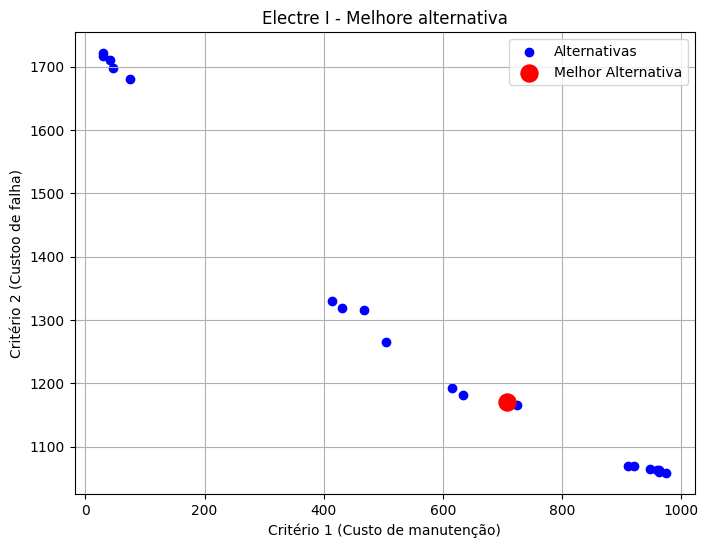

f1     708.000000
f2    1170.244529
f3    1191.575716
f4       1.307826
Name: 19, dtype: float64

In [44]:
ranking = electre_1(df_sol,weights)

print("Ranking (melhor para pior):")

for pos, alt in enumerate(ranking):
    print(f"{pos+1}º lugar: A{alt}")

# --- Gráfico das duas primeiras colunas ---

plt.figure(figsize=(8,6))

# Plota todas as alternativas
plt.scatter(pareto[:, 0], pareto[:, 1], c='blue', label='Alternativas')

# Destaca a melhor alternativa em vermelho
melhor = ranking[0]
plt.scatter(pareto[melhor[0], 0], pareto[melhor[0], 1], c='red', s=150, label='Melhor Alternativa')

plt.xlabel('Critério 1 (Custo de manutenção)')
plt.ylabel('Critério 2 (Custoo de falha)')
plt.title('Electre I - Melhore alternativa')
plt.legend()
plt.grid(True)
plt.show()

df_sol.iloc[ranking[0][0]]

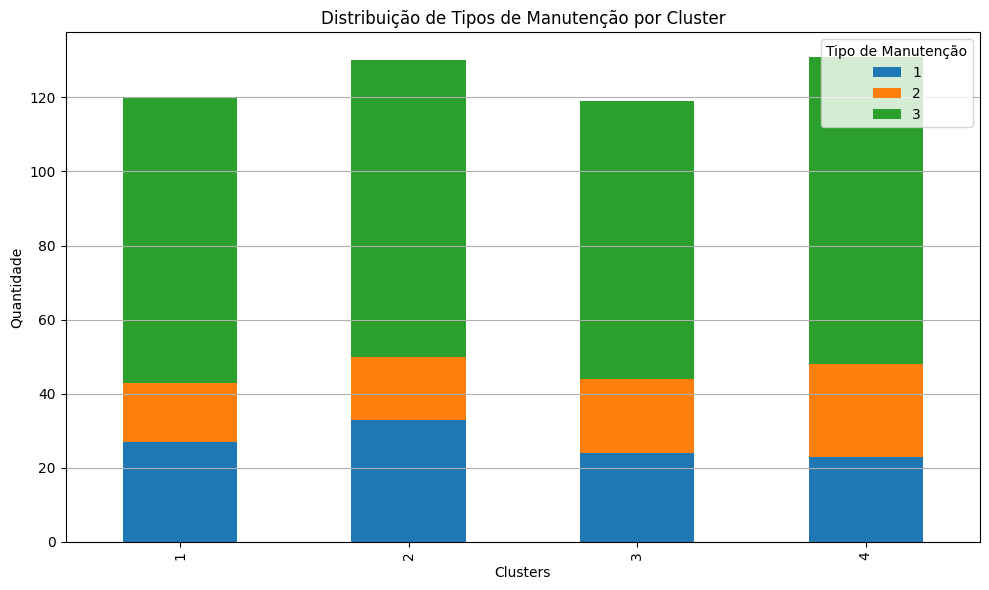

In [45]:
df_cluster_manutencao = pd.DataFrame({
        'ID_Cluster': equipDB["ID_Cluster"],
        'Tipo_Manutencao': result.iloc[ranking[0][0]]
    })

    # Tabela cruzada: linhas = clusters, colunas = tipos de manutenção
tabela = pd.crosstab(df_cluster_manutencao['ID_Cluster'], df_cluster_manutencao['Tipo_Manutencao'])

# Plotando distribuição por cluster
tabela.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Distribuição de Tipos de Manutenção por Cluster")
plt.xlabel("Clusters")
plt.ylabel("Quantidade")
plt.legend(title="Tipo de Manutenção")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Promethi II

Ranking (melhor para pior):
1º lugar: A17 (fluxo líquido = 0.2368)
2º lugar: A20 (fluxo líquido = 0.2211)
3º lugar: A19 (fluxo líquido = 0.2000)
4º lugar: A1 (fluxo líquido = 0.1842)
5º lugar: A10 (fluxo líquido = 0.1105)
6º lugar: A3 (fluxo líquido = 0.1053)
7º lugar: A6 (fluxo líquido = 0.0947)
8º lugar: A9 (fluxo líquido = 0.0684)
9º lugar: A11 (fluxo líquido = 0.0316)
10º lugar: A8 (fluxo líquido = 0.0105)
11º lugar: A16 (fluxo líquido = 0.0105)
12º lugar: A5 (fluxo líquido = -0.0105)
13º lugar: A15 (fluxo líquido = -0.0842)
14º lugar: A4 (fluxo líquido = -0.1000)
15º lugar: A18 (fluxo líquido = -0.1158)
16º lugar: A12 (fluxo líquido = -0.1158)
17º lugar: A2 (fluxo líquido = -0.1316)
18º lugar: A13 (fluxo líquido = -0.2000)
19º lugar: A14 (fluxo líquido = -0.2474)
20º lugar: A7 (fluxo líquido = -0.2684)


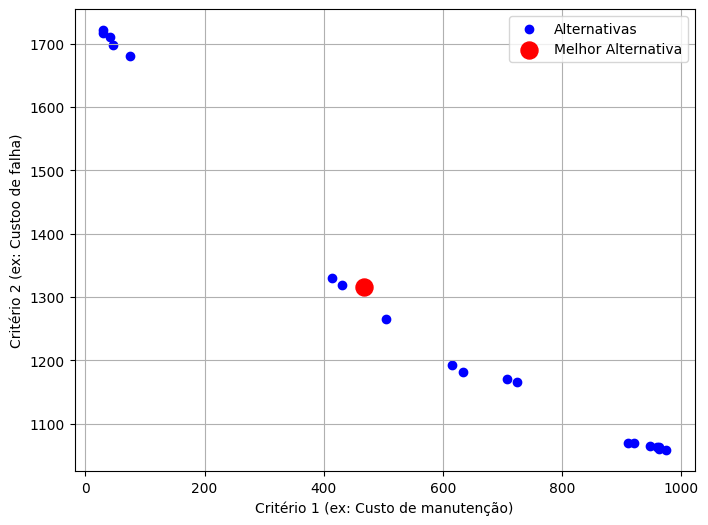

f1     467.000000
f2    1316.747135
f3     813.394617
f4       1.425849
Name: 16, dtype: float64

In [ ]:
def normalize(X, maximize):
    X_norm = np.zeros_like(X, dtype=float)
    for j in range(X.shape[1]):
        col = X[:, j]
        min_val = np.min(col)
        max_val = np.max(col)
        if max_val - min_val == 0:
            X_norm[:, j] = 0.5
        elif maximize[j]:
            X_norm[:, j] = (col - min_val) / (max_val - min_val)
        else:
            X_norm[:, j] = (max_val - col) / (max_val - min_val)
    return X_norm

def preference_function(d):
    return 0 if d <= 0 else 1

def preference_matrix(X_norm, weights):
    n, m = X_norm.shape
    P = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                soma = 0
                for c in range(m):
                    d = X_norm[i, c] - X_norm[j, c]
                    p = preference_function(d)
                    soma += weights[c] * p
                P[i, j] = soma
    return P

def calculate_flows(P):
    n = P.shape[0]
    phi_plus = np.sum(P, axis=1) / (n - 1)
    phi_minus = np.sum(P, axis=0) / (n - 1)
    phi_liquido = phi_plus - phi_minus
    return phi_plus, phi_minus, phi_liquido

def promethee_ii(X, weights, maximize):
    X_norm = normalize(X, maximize)
    P = preference_matrix(X_norm, weights)
    phi_plus, phi_minus, phi_liquido = calculate_flows(P)
    ranking = np.argsort(-phi_liquido)
    return ranking, phi_liquido, P

# Exemplo com seus dados

maximize = np.array([False, False, False, True])

ranking, phi_liquido, P = promethee_ii(pareto, weights, maximize)

print("Ranking (melhor para pior):")
for pos, alt in enumerate(ranking):
    print(f"{pos+1}º lugar: A{alt+1} (fluxo líquido = {phi_liquido[alt]:.4f})")

# --- Gráfico das duas primeiras colunas ---

plt.figure(figsize=(8,6))

# Plota todas as alternativas
plt.scatter(pareto[:, 0], pareto[:, 1], c='blue', label='Alternativas')

# Destaca a melhor alternativa em vermelho
melhor = ranking[0]
plt.scatter(pareto[melhor, 0], pareto[melhor, 1], c='red', s=150, label='Melhor Alternativa')

plt.xlabel('Critério 1 (ex: Custo de manutenção)')
plt.ylabel('Critério 2 (ex: Custoo de falha)')
# plt.title('PROMETHEE II - Melhores alternativas (duas primeiras colunas)')
plt.legend()
plt.grid(True)
plt.show()

df_sol.iloc[ranking[0]]


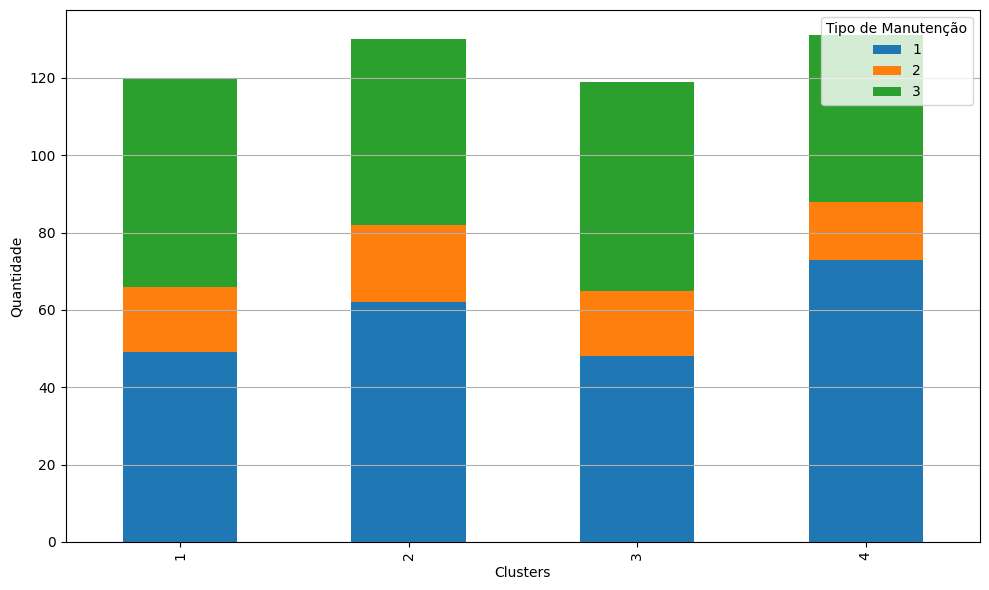

In [37]:
df = pd.DataFrame({
        'ID_Cluster': equipDB["ID_Cluster"],
        'Tipo_Manutencao': result.iloc[ranking[0]]
    })

    # Tabela cruzada: linhas = clusters, colunas = tipos de manutenção
tabela = pd.crosstab(df['ID_Cluster'], df['Tipo_Manutencao'])

# Plotando distribuição por cluster
tabela.plot(kind='bar', stacked=True, figsize=(10, 6))
# plt.title("Distribuição de Tipos de Manutenção por Cluster")
plt.xlabel("Clusters")
plt.ylabel("Quantidade")
plt.legend(title="Tipo de Manutenção")
plt.grid(axis='y')
plt.tight_layout()
plt.show()